# Construcción de variables de carga competitiva enriquecida

## 1. Objetivo del notebook

Este notebook amplía el conjunto de datos jugador–partido mediante la construcción de variables temporales destinadas a representar dimensiones de la carga competitiva que no quedan completamente recogidas por los acumulados de 365 días, 180 días y temporada.

Las nuevas variables se construyen a partir de información estrictamente anterior a la fecha del torneo analizado. El objetivo es evitar que los resultados o el volumen del torneo actual intervengan en la definición de sus propios predictores.

El bloque representa tres dimensiones complementarias:

$$
\text{carga de la última participación}
+
\text{separación calendárica}
+
\text{densidad competitiva reciente}.
$$

En concreto, se construirán:

* el volumen disputado en la última fecha competitiva observable;
* los días transcurridos entre el inicio de la participación actual y el de la participación anterior;
* el número de semanas naturales con alguna fecha de inicio competitiva durante los 56 días previos;
* un indicador de disponibilidad completa del historial de 56 días.

## 1.1. Unidad temporal de construcción

Aunque el conjunto principal presenta una fila por jugador y partido, las variables temporales se calculan inicialmente sobre una estructura jugador–fecha.

Esta estructura evita establecer un orden artificial entre torneos que comparten la misma fecha de inicio. Posteriormente, las variables se incorporan a las estructuras jugador–torneo y jugador–partido.

El flujo de construcción es:

$$
\text{jugador–fecha}
\longrightarrow
\text{jugador–torneo}
\longrightarrow
\text{jugador–partido}.
$$

## 1.2. Bloques temporales independientes

La muestra de estudio se organiza en dos grandes bloques temporales:

$$
2009\text{--}2019
$$

y:

$$
2022\text{--}2024.
$$

Sin embargo, para construir variables históricas se conservan dos años auxiliares:

$$
2008
$$

y:

$$
2021.
$$

El año 2008 se utiliza como buffer para disponer de historial previo al comienzo del bloque 2009--2019, mientras que 2021 se utiliza como buffer para construir el historial previo al bloque 2022--2024. Estos años no forman parte de la muestra analítica principal, pero sí permiten calcular variables de carga sin comenzar artificialmente desde cero.

Por este motivo, los historiales se construyen de forma independiente en dos bloques operativos:

$$
2008\text{--}2019
$$

y:

$$
2021\text{--}2024.
$$

La primera participación observada en 2022 puede utilizar información de 2021, pero nunca se conecta con participaciones de 2019, ya que el año 2020 no forma parte del dataset operativo.

## 1.3. Principio de temporalidad

Para una observación actual del jugador (i) en la fecha (T_{i,t}), toda variable histórica se calcula utilizando únicamente fechas anteriores:

$$
T_{i,k}<T_{i,t}.
$$

La fecha actual queda excluida de todas las ventanas y desplazamientos. De este modo, se evita la fuga de información y se garantiza que las variables puedan interpretarse como información disponible antes de la participación analizada.

Las variables específicas de superficie no se desarrollan en este notebook y quedan reservadas como posible ampliación posterior.



In [1]:
# Importa pandas para cargar, manipular y transformar datasets en formato tabla.
import pandas as pd

# Importa matplotlib para crear gráficos básicos.
import matplotlib.pyplot as plt

from matplotlib.patches import FancyBboxPatch

In [2]:
# ============================================================
# 1. CARGA DE LOS DATASETS Y DEFINICIÓN DE BLOQUES TEMPORALES
# ============================================================

# Cargo el dataset principal a nivel jugador–partido.
data = pd.read_csv(
    "df_jugador_cargas.csv",
    low_memory=False
)

# Cargo la tabla con una fila por jugador y torneo.
df_jugador_torneo = pd.read_csv(
    "df_jugador_torneo_cargas.csv",
    low_memory=False
)

# Cargo la tabla con una fila por jugador y fecha competitiva.
df_jugador_fecha = pd.read_csv(
    "df_jugador_fecha_cargas.csv",
    low_memory=False
)

# Convierto las fechas al formato temporal adecuado.
data["fecha_torneo"] = pd.to_datetime(
    data["fecha_torneo"],
    errors="raise"
)

df_jugador_torneo["fecha_torneo"] = pd.to_datetime(
    df_jugador_torneo["fecha_torneo"],
    errors="raise"
)

df_jugador_fecha["fecha_torneo"] = pd.to_datetime(
    df_jugador_fecha["fecha_torneo"],
    errors="raise"
)

# Guardo dimensiones iniciales para comprobar después
# que las variables enriquecidas no cambian la muestra.
filas_iniciales = len(data)
columnas_iniciales = data.shape[1]
partidos_iniciales = data["_id_partido"].nunique()

filas_torneo_iniciales = len(df_jugador_torneo)
columnas_torneo_iniciales = df_jugador_torneo.shape[1]

filas_fecha_iniciales = len(df_jugador_fecha)
columnas_fecha_iniciales = df_jugador_fecha.shape[1]

# Comprobaciones estructurales mínimas después del notebook de carga acumulada.
# No fijo dimensiones exactas para evitar que cambios legítimos anteriores
# rompan este notebook.

assert filas_iniciales > 0
assert partidos_iniciales > 0
assert filas_torneo_iniciales > 0
assert filas_fecha_iniciales > 0

assert data["_id_partido"].notna().all()

assert (
    data.groupby("_id_partido")
    .size()
    .eq(2)
    .all()
), (
    "Algún partido no conserva exactamente dos perspectivas jugador-partido."
)

columnas_minimas_data = [
    "_id_partido",
    "jugador_id",
    "identificador_torneo",
    "fecha_torneo",
    "match_year"
]

columnas_minimas_torneo = [
    "jugador_id",
    "identificador_torneo",
    "fecha_torneo",
    "match_year"
]

columnas_minimas_fecha = [
    "jugador_id",
    "fecha_torneo",
    "match_year",
    "juegos_fecha",
    "sets_fecha",
    "partidos_fecha",
    "torneos_fecha"
]

assert set(columnas_minimas_data).issubset(data.columns)
assert set(columnas_minimas_torneo).issubset(df_jugador_torneo.columns)
assert set(columnas_minimas_fecha).issubset(df_jugador_fecha.columns)

# Columnas temporales de control.
columnas_temporales = [
    "es_muestra_estudio",
    "es_buffer_carga",
    "es_desarrollo_modelo",
    "es_validacion_temporal"
]

for df_nombre, df in {
    "data": data,
    "df_jugador_torneo": df_jugador_torneo,
    "df_jugador_fecha": df_jugador_fecha
}.items():

    assert set(columnas_temporales).issubset(df.columns), (
        f"Faltan columnas temporales en {df_nombre}."
    )

    assert (
        df["es_buffer_carga"]
        + df["es_desarrollo_modelo"]
        + df["es_validacion_temporal"]
    ).eq(1).all(), (
        f"La asignación temporal no es excluyente en {df_nombre}."
    )

    assert (
        df["es_desarrollo_modelo"]
        + df["es_validacion_temporal"]
    ).eq(df["es_muestra_estudio"]).all(), (
        f"La muestra de estudio no coincide con desarrollo + validación en {df_nombre}."
    )

    assert 2020 not in df["match_year"].unique(), (
        f"2020 aparece indebidamente en {df_nombre}."
    )

# ------------------------------------------------------------
# Definición de los bloques temporales independientes
# ------------------------------------------------------------

# Creo una variable auxiliar para impedir que el historial
# de 2019 se conecte con el bloque 2021–2024.
df_jugador_fecha["bloque_temporal"] = pd.Series(
    pd.NA,
    index=df_jugador_fecha.index,
    dtype="string"
)

mascara_bloque_2008_2019 = (
    df_jugador_fecha["match_year"]
    .between(2008, 2019)
)

mascara_bloque_2021_2024 = (
    df_jugador_fecha["match_year"]
    .between(2021, 2024)
)

df_jugador_fecha.loc[
    mascara_bloque_2008_2019,
    "bloque_temporal"
] = "2008_2019"

df_jugador_fecha.loc[
    mascara_bloque_2021_2024,
    "bloque_temporal"
] = "2021_2024"

# ------------------------------------------------------------
# Comprobaciones iniciales
# ------------------------------------------------------------

assert df_jugador_fecha["bloque_temporal"].notna().all(), (
    "Existen observaciones que no pertenecen "
    "a ninguno de los dos bloques temporales."
)

assert set(df_jugador_fecha["bloque_temporal"].unique()) == {
    "2008_2019",
    "2021_2024"
}

assert df_jugador_fecha.loc[
    df_jugador_fecha["match_year"].isin([2008, 2021]),
    "es_buffer_carga"
].eq(1).all()

assert df_jugador_fecha.loc[
    df_jugador_fecha["match_year"].between(2009, 2019)
    | df_jugador_fecha["match_year"].between(2022, 2024),
    "es_muestra_estudio"
].eq(1).all()

numero_historiales_jugador_bloque = (
    df_jugador_fecha[
        [
            "jugador_id",
            "bloque_temporal"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

print("Jugador–partido:", data.shape)
print("Jugador–torneo:", df_jugador_torneo.shape)
print("Jugador–fecha:", df_jugador_fecha.shape)

print(
    "Historiales jugador–bloque:",
    numero_historiales_jugador_bloque
)

display(
    df_jugador_fecha[
        "bloque_temporal"
    ]
    .value_counts()
    .rename_axis("bloque_temporal")
    .to_frame("numero_observaciones")
)

Jugador–partido: (94030, 93)
Jugador–torneo: (50051, 30)
Jugador–fecha: (50050, 27)
Historiales jugador–bloque: 2198


,numero_observaciones
bloque_temporal,
2008_2019,37638
2021_2024,12412


## 2. Carga de la última participación competitiva

La primera ampliación será la carga correspondiente a la participación competitiva inmediatamente anterior de cada jugador dentro del mismo bloque temporal.

La variable principal será:

```text
juegos_ultima_fecha_competitiva
```

y representará el número total de juegos disputados por el jugador en la fecha competitiva anterior.

El cálculo se realizará sobre `df_jugador_fecha`, que contiene una sola fila por jugador y fecha. Esta estructura evita establecer un orden artificial entre los dos torneos que, en un caso concreto, comparten la misma fecha de inicio.

Para un jugador ($i$) y una participación actual ($t$), la variable se define como:

$$
L_{i,t}=J_{i,t-1},
$$

donde ($J_{i,t-1}$) representa los juegos disputados en la fecha competitiva inmediatamente anterior dentro del mismo bloque temporal.

También se conservarán inicialmente los sets, partidos y torneos correspondientes a esa participación anterior, con el objetivo de evaluar posteriormente su posible redundancia respecto al volumen expresado en juegos.

La primera observación disponible de cada combinación jugador–bloque no tendrá una participación previa observable. En estos casos, el valor se mantendrá como ausente y no se sustituirá por cero, porque la ausencia de historial dentro de la muestra no implica que el jugador no hubiera competido anteriormente.


In [3]:

# ============================================================
# 2. CARGA DE LA ÚLTIMA PARTICIPACIÓN COMPETITIVA
# ============================================================

# Ordeno cronológicamente cada historial independiente.
df_jugador_fecha = (
    df_jugador_fecha
    .sort_values(
        [
            "jugador_id",
            "bloque_temporal",
            "fecha_torneo"
        ],
        kind="mergesort"
    )
    .reset_index(drop=True)
)


# Cada jugador dispone de un historial independiente
# en cada bloque temporal.
grupo_jugador_bloque = df_jugador_fecha.groupby(
    [
        "jugador_id",
        "bloque_temporal"
    ],
    sort=False
)


# Fecha competitiva inmediatamente anterior.
df_jugador_fecha["fecha_ultima_competitiva"] = (
    grupo_jugador_bloque["fecha_torneo"]
    .shift(1)
)


# Volumen disputado en la fecha competitiva anterior.
df_jugador_fecha["juegos_ultima_fecha_competitiva"] = (
    grupo_jugador_bloque["juegos_fecha"]
    .shift(1)
    .astype("Int64")
)

df_jugador_fecha["sets_ultima_fecha_competitiva"] = (
    grupo_jugador_bloque["sets_fecha"]
    .shift(1)
    .astype("Int64")
)

df_jugador_fecha["partidos_ultima_fecha_competitiva"] = (
    grupo_jugador_bloque["partidos_fecha"]
    .shift(1)
    .astype("Int64")
)

df_jugador_fecha["torneos_ultima_fecha_competitiva"] = (
    grupo_jugador_bloque["torneos_fecha"]
    .shift(1)
    .astype("Int64")
)


# ------------------------------------------------------------
# Validación de las primeras observaciones
# ------------------------------------------------------------

primera_observacion_bloque = (
    grupo_jugador_bloque
    .cumcount()
    .eq(0)
)


columnas_ultima_participacion = [
    "fecha_ultima_competitiva",
    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva"
]


for columna in columnas_ultima_participacion:

    assert (
        df_jugador_fecha[columna]
        .isna()
        .equals(primera_observacion_bloque)
    )


numero_historiales_jugador_bloque = (
    df_jugador_fecha[
        [
            "jugador_id",
            "bloque_temporal"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


assert (
    primera_observacion_bloque.sum()
    == numero_historiales_jugador_bloque
)




# Las fechas anteriores deben ser estrictamente previas.
mascara_historial_anterior = (
    df_jugador_fecha[
        "fecha_ultima_competitiva"
    ].notna()
)

assert (
    df_jugador_fecha.loc[
        mascara_historial_anterior,
        "fecha_ultima_competitiva"
    ]
    <
    df_jugador_fecha.loc[
        mascara_historial_anterior,
        "fecha_torneo"
    ]
).all()


print(
    "Historiales jugador–bloque:",
    numero_historiales_jugador_bloque
)

print(
    "Observaciones con participación anterior:",
    mascara_historial_anterior.sum()
)

print(
    "Observaciones sin participación anterior:",
    primera_observacion_bloque.sum()
)

print(
    "Carga de la última participación construida correctamente."
)



Historiales jugador–bloque: 2198
Observaciones con participación anterior: 47852
Observaciones sin participación anterior: 2198
Carga de la última participación construida correctamente.


In [4]:

# Selecciono un jugador con un historial amplio
# para comprobar el desplazamiento temporal.
jugador_ejemplo = (
    df_jugador_fecha["jugador_id"]
    .value_counts()
    .idxmax()
)


display(
    df_jugador_fecha.loc[
        df_jugador_fecha["jugador_id"].eq(jugador_ejemplo),
        [
            "jugador_id",
            "jugador_nombre",
            "fecha_torneo",
            "juegos_fecha",
            "fecha_ultima_competitiva",
            "juegos_ultima_fecha_competitiva",
            "sets_ultima_fecha_competitiva",
            "partidos_ultima_fecha_competitiva",
            "torneos_ultima_fecha_competitiva"
        ]
    ].head(12)
)



,jugador_id,jugador_nombre,fecha_torneo,juegos_fecha,fecha_ultima_competitiva,juegos_ultima_fecha_competitiva,sets_ultima_fecha_competitiva,partidos_ultima_fecha_competitiva,torneos_ultima_fecha_competitiva
22134,104926,Fabio Fognini,2008-01-14,43,NaT,<NA>,<NA>,<NA>,<NA>
22135,104926,Fabio Fognini,2008-01-28,71,2008-01-14,43,5,1,1
22136,104926,Fabio Fognini,2008-02-11,100,2008-01-28,71,7,3,1
22137,104926,Fabio Fognini,2008-02-18,47,2008-02-11,100,10,4,1
22138,104926,Fabio Fognini,2008-02-25,22,2008-02-18,47,5,2,1
22139,104926,Fabio Fognini,2008-03-13,46,2008-02-25,22,2,1,1
22140,104926,Fabio Fognini,2008-06-09,78,2008-03-13,46,5,2,1
22141,104926,Fabio Fognini,2008-06-15,21,2008-06-09,78,7,4,1
22142,104926,Fabio Fognini,2008-06-23,28,2008-06-15,21,2,1,1
22143,104926,Fabio Fognini,2008-07-07,32,2008-06-23,28,3,1,1


## 3. Intervalo entre participaciones competitivas consecutivas

A continuación construyo una variable que represente la separación temporal entre la participación competitiva actual y la inmediatamente anterior.

La variable se denominará:

`dias_entre_inicios_competitivos`

Para un jugador (i) y una participación actual (t), se define como:


$D_{i,t}$=
$T_{i,t}$-
$T_{i,t-1}$


donde:

* ($T_{i,t}$) es la fecha de inicio de la participación competitiva actual;
* ($T_{i,t-1}$) representa la fecha de inicio de la participación inmediatamente anterior del mismo jugador dentro del mismo bloque temporal.

La variable mide la separación calendárica entre inicios competitivos. No representa exactamente los días de descanso o recuperación del jugador, ya que la participación anterior puede haberse prolongado durante varios días.
La primera observación de cada combinación jugador–bloque permanecerá como valor ausente, puesto que no existe una participación anterior observable con la que calcular el intervalo.


In [5]:

# ============================================================
# 3. INTERVALO ENTRE PARTICIPACIONES COMPETITIVAS
# ============================================================

# Calculo el número de días entre la fecha actual
# y la última participación observable dentro del mismo bloque.
df_jugador_fecha["dias_entre_inicios_competitivos"] = (
    (
        df_jugador_fecha["fecha_torneo"]
        - df_jugador_fecha["fecha_ultima_competitiva"]
    )
    .dt.days
    .astype("Int64")
)


# ------------------------------------------------------------
# Validación del intervalo
# ------------------------------------------------------------

primera_observacion_bloque = (
    df_jugador_fecha
    .groupby(
        [
            "jugador_id",
            "bloque_temporal"
        ],
        sort=False
    )
    .cumcount()
    .eq(0)
)


# Solo las primeras observaciones de cada jugador–bloque
# deben carecer de intervalo anterior.
assert (
    df_jugador_fecha[
        "dias_entre_inicios_competitivos"
    ]
    .isna()
    .equals(primera_observacion_bloque)
)


mascara_intervalo_disponible = (
    df_jugador_fecha[
        "dias_entre_inicios_competitivos"
    ].notna()
)


# Todo intervalo disponible debe ser estrictamente positivo.
assert (
    df_jugador_fecha.loc[
        mascara_intervalo_disponible,
        "dias_entre_inicios_competitivos"
    ]
    .gt(0)
    .all()
)


# Compruebo que el intervalo coincide exactamente
# con la diferencia entre ambas fechas.
intervalo_control = (
    (
        df_jugador_fecha["fecha_torneo"]
        - df_jugador_fecha["fecha_ultima_competitiva"]
    )
    .dt.days
    .astype("Int64")
)

pd.testing.assert_series_equal(
    df_jugador_fecha[
        "dias_entre_inicios_competitivos"
    ],
    intervalo_control,
    check_dtype=False,
    check_names=False
)


print(
    "Observaciones con intervalo disponible:",
    mascara_intervalo_disponible.sum()
)

print(
    "Observaciones sin intervalo anterior:",
    primera_observacion_bloque.sum()
)

display(
    df_jugador_fecha[
        "dias_entre_inicios_competitivos"
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame("dias")
)

print(
    "Intervalo entre participaciones construido correctamente."
)



Observaciones con intervalo disponible: 47852
Observaciones sin intervalo anterior: 2198


,dias
count,47852.0
mean,46.026812
std,121.968205
min,1.0
25%,7.0
50%,14.0
75%,28.0
90%,98.0
95%,196.0
99%,581.0


Intervalo entre participaciones construido correctamente.


## 4. Densidad competitiva durante los 56 días anteriores

La carga acumulada y el intervalo entre participaciones no describen completamente cómo se distribuye la competición durante el periodo reciente.

Dos jugadores pueden haber disputado un número similar de juegos, pero presentar calendarios diferentes:

* uno puede concentrar la actividad en pocas semanas;
* otro puede competir de forma continuada durante varias semanas.

Para representar esta dimensión construiré:

`semanas_con_competicion_56d`

y representará el número de semanas naturales distintas que contienen al menos una fecha de inicio competitiva del jugador dentro de los 56 días anteriores a la participación actual.


Para un jugador \(i\) y una participación actual \(t\), la variable se define como:

$$
S_{i,t}^{56}
=
\#\{w(T_{i,k}) : T_{i,t}-56 \leq T_{i,k}<T_{i,t}\}.
$$



donde:

* ($T_{i,k}$) representa una fecha competitiva anterior;
* ($w(T_{i,k})$) identifica la semana natural a la que pertenece esa fecha;
* el símbolo (#) representa el número de semanas distintas.

La fecha actual queda excluida de la ventana, por lo que la variable solo utiliza información disponible antes del torneo que se analiza.

También se construirá:

historial_56d_completo

que indicará si la observación dispone de los 56 días completos de historial potencialmente observable dentro de su bloque temporal.


In [6]:

# ============================================================
# 4. DENSIDAD COMPETITIVA EN LOS 56 DÍAS ANTERIORES
# ============================================================

from collections import Counter, deque


# Aseguro el orden cronológico dentro de cada historial.
df_jugador_fecha = (
    df_jugador_fecha
    .sort_values(
        [
            "jugador_id",
            "bloque_temporal",
            "fecha_torneo"
        ],
        kind="mergesort"
    )
    .reset_index(drop=True)
)


# Almacenaré el número de semanas naturales distintas
# con alguna fecha competitiva previa en los últimos 56 días.
semanas_con_competicion_56d = []


for (
    jugador_id,
    bloque_temporal
), grupo in df_jugador_fecha.groupby(
    [
        "jugador_id",
        "bloque_temporal"
    ],
    sort=False
):

    # Cola con las fechas previas que permanecen
    # dentro de la ventana temporal de 56 días.
    fechas_ventana = deque()

    # Número de participaciones registradas en cada semana natural.
    contador_semanas = Counter()

    for fecha_actual in grupo["fecha_torneo"]:

        limite_inferior = (
            fecha_actual
            - pd.Timedelta(days=56)
        )

        # Elimino las fechas anteriores que han quedado
        # fuera de la ventana [fecha_actual - 56, fecha_actual).
        while (
            fechas_ventana
            and fechas_ventana[0][0] < limite_inferior
        ):

            fecha_antigua, semana_antigua = (
                fechas_ventana.popleft()
            )

            contador_semanas[semana_antigua] -= 1

            if contador_semanas[semana_antigua] == 0:
                del contador_semanas[semana_antigua]

        # Cuento las semanas distintas antes de introducir
        # la fecha actual, evitando fuga de información.
        semanas_con_competicion_56d.append(
            len(contador_semanas)
        )

        semana_actual = fecha_actual.to_period("W-SUN")

        fechas_ventana.append(
            (
                fecha_actual,
                semana_actual
            )
        )

        contador_semanas[semana_actual] += 1


df_jugador_fecha[
    "semanas_con_competicion_56d"
] = pd.Series(
    semanas_con_competicion_56d,
    index=df_jugador_fecha.index,
    dtype="Int64"
)


# ------------------------------------------------------------
# Indicador de cobertura completa de 56 días
# ------------------------------------------------------------

# La cobertura depende del comienzo observable de cada bloque,
# no de la primera aparición individual de cada jugador.
fecha_inicio_bloque = (
    df_jugador_fecha
    .groupby(
        "bloque_temporal"
    )["fecha_torneo"]
    .transform("min")
)

df_jugador_fecha["historial_56d_completo"] = (
    (
        df_jugador_fecha["fecha_torneo"]
        - fecha_inicio_bloque
    )
    .dt.days
    .ge(56)
)

# Los años buffer se usan para calcular historial,
# pero no forman parte de la muestra de estudio.
df_jugador_fecha.loc[
    df_jugador_fecha["es_buffer_carga"].eq(1),
    "historial_56d_completo"
] = False

# ------------------------------------------------------------
# Validaciones
# ------------------------------------------------------------

assert df_jugador_fecha[
    "semanas_con_competicion_56d"
].notna().all()

assert df_jugador_fecha[
    "historial_56d_completo"
].notna().all()

assert (
    df_jugador_fecha[
        "semanas_con_competicion_56d"
    ]
    .between(0, 9)
    .all()
)

assert df_jugador_fecha.loc[
    df_jugador_fecha["es_buffer_carga"].eq(1),
    "historial_56d_completo"
].eq(False).all()

assert df_jugador_fecha.loc[
    df_jugador_fecha["es_muestra_estudio"].eq(1),
    "historial_56d_completo"
].notna().all()


mascara_muestra_estudio = (
    df_jugador_fecha["es_muestra_estudio"].eq(1)
)

n_muestra_estudio = int(
    mascara_muestra_estudio.sum()
)

n_historial_56d_completo = int(
    df_jugador_fecha.loc[
        mascara_muestra_estudio,
        "historial_56d_completo"
    ].sum()
)

n_historial_56d_incompleto = (
    n_muestra_estudio
    - n_historial_56d_completo
)

print(
    "Observaciones jugador–fecha de la muestra de estudio:",
    n_muestra_estudio
)

print(
    "Con historial completo de 56 días:",
    n_historial_56d_completo
)

print(
    "Con historial incompleto de 56 días:",
    n_historial_56d_incompleto
)

display(
    df_jugador_fecha[
        "semanas_con_competicion_56d"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("semanas")
    .to_frame("numero_observaciones")
)

print(
    "Densidad competitiva calculada correctamente "
    "por jugador y bloque temporal."
)



Observaciones jugador–fecha de la muestra de estudio: 43863
Con historial completo de 56 días: 43863
Con historial incompleto de 56 días: 0


,numero_observaciones
semanas,
0,9699
1,6089
2,6471
3,9181
4,10518
5,6217
6,1667
7,207
8,1


Densidad competitiva calculada correctamente por jugador y bloque temporal.


## 5. Reincorporación de las variables de carga enriquecida

Las variables históricas se han construido a nivel jugador–fecha, que constituye la unidad temporal adecuada para evitar establecer un orden artificial entre participaciones con la misma fecha de inicio.

Una vez calculadas, se trasladan primero a la estructura jugador–torneo y posteriormente al conjunto principal jugador–partido. Las incorporaciones se realizan mediante claves únicas y relaciones `many-to-one`, comprobando que el proceso no modifique el número de observaciones ni de partidos.

De este modo, todos los partidos disputados por un jugador dentro de una misma participación reciben las mismas variables históricas calculadas antes de su inicio.

In [7]:

# ============================================================
# 5. INCORPORACIÓN DE LAS VARIABLES DE CARGA ENRIQUECIDA
# ============================================================

columnas_carga_enriquecida = [
    "fecha_ultima_competitiva",
    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva",
    "dias_entre_inicios_competitivos",
    "semanas_con_competicion_56d",
    "historial_56d_completo"
]


# ------------------------------------------------------------
# Incorporación desde jugador–fecha a jugador–torneo
# ------------------------------------------------------------

cargas_enriquecidas_jugador_fecha = (
    df_jugador_fecha[
        [
            "jugador_id",
            "fecha_torneo"
        ]
        + columnas_carga_enriquecida
    ]
    .copy()
)


# La clave jugador–fecha debe ser única.
assert not cargas_enriquecidas_jugador_fecha.duplicated(
    subset=[
        "jugador_id",
        "fecha_torneo"
    ]
).any()


# Elimino previamente las columnas para que la celda
# pueda ejecutarse de nuevo sin crear sufijos _x y _y.
df_jugador_torneo = df_jugador_torneo.drop(
    columns=columnas_carga_enriquecida,
    errors="ignore"
)


df_jugador_torneo = df_jugador_torneo.merge(
    cargas_enriquecidas_jugador_fecha,
    on=[
        "jugador_id",
        "fecha_torneo"
    ],
    how="left",
    validate="many_to_one"
)




# ------------------------------------------------------------
# Incorporación desde jugador–torneo a jugador–partido
# ------------------------------------------------------------

cargas_enriquecidas_jugador_torneo = (
    df_jugador_torneo[
        [
            "jugador_id",
            "identificador_torneo"
        ]
        + columnas_carga_enriquecida
    ]
    .copy()
)


# La clave jugador–torneo debe ser única.
assert not cargas_enriquecidas_jugador_torneo.duplicated(
    subset=[
        "jugador_id",
        "identificador_torneo"
    ]
).any()


# Elimino previamente las columnas para permitir
# una nueva ejecución segura de la celda.
data = data.drop(
    columns=columnas_carga_enriquecida,
    errors="ignore"
)


data = data.merge(
    cargas_enriquecidas_jugador_torneo,
    on=[
        "jugador_id",
        "identificador_torneo"
    ],
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# Comprobaciones estructurales
# ------------------------------------------------------------

assert len(data) == filas_iniciales
assert data["_id_partido"].nunique() == partidos_iniciales

assert df_jugador_torneo.shape[1] == (
    columnas_torneo_iniciales + len(columnas_carga_enriquecida)
)

assert data.shape[1] == (
    columnas_iniciales + len(columnas_carga_enriquecida)
)

assert set(
    columnas_carga_enriquecida
).issubset(df_jugador_torneo.columns)

assert set(
    columnas_carga_enriquecida
).issubset(data.columns)


print(
    "Dimensiones de df_jugador_torneo:",
    df_jugador_torneo.shape
)

print(
    "Dimensiones de data:",
    data.shape
)

print(
    "Variables enriquecidas incorporadas correctamente."
)


display(
    data[
        [
            "_id_partido",
            "jugador_id",
            "jugador_nombre",
            "nombre_torneo",
            "fecha_torneo",
            "juegos_ultima_fecha_competitiva",
            "dias_entre_inicios_competitivos",
            "semanas_con_competicion_56d",
            "historial_56d_completo"
        ]
    ]
    .head(12)
)



Dimensiones de df_jugador_torneo: (50051, 38)
Dimensiones de data: (94030, 101)
Variables enriquecidas incorporadas correctamente.


,_id_partido,jugador_id,jugador_nombre,nombre_torneo,fecha_torneo,juegos_ultima_fecha_competitiva,dias_entre_inicios_competitivos,semanas_con_competicion_56d,historial_56d_completo
0,2008-339__1,104534,Dudi Sela,Adelaide,2007-12-31,<NA>,<NA>,0,False
1,2008-339__1,103720,Lleyton Hewitt,Adelaide,2007-12-31,<NA>,<NA>,0,False
2,2008-339__2,104268,Alejandro Falla,Adelaide,2007-12-31,<NA>,<NA>,0,False
3,2008-339__2,104076,Jose Acasuso,Adelaide,2007-12-31,<NA>,<NA>,0,False
4,2008-339__3,104979,Andrey Golubev,Adelaide,2007-12-31,<NA>,<NA>,0,False
5,2008-339__3,105208,Ernests Gulbis,Adelaide,2007-12-31,<NA>,<NA>,0,False
6,2008-339__4,104542,Jo-Wilfried Tsonga,Adelaide,2007-12-31,<NA>,<NA>,0,False
7,2008-339__4,103812,Victor Hanescu,Adelaide,2007-12-31,<NA>,<NA>,0,False
8,2008-339__5,103657,Ivo Klec,Adelaide,2007-12-31,<NA>,<NA>,0,False
9,2008-339__5,103813,Jarkko Nieminen,Adelaide,2007-12-31,<NA>,<NA>,0,False


## Validación final de las variables de carga enriquecida

Antes de guardar los nuevos archivos, compruebo que las variables enriquecidas se han construido e incorporado correctamente.

La validación se centra en verificar que:

* el número de observaciones y partidos no ha cambiado;
* cada partido mantiene sus dos perspectivas;
* la primera participación observable de cada combinación jugador–bloque es la única que carece de historial anterior;
* la fecha competitiva anterior es siempre estrictamente previa a la actual;
* `dias_entre_inicios_competitivos` coincide con la diferencia exacta entre ambas fechas;
* los juegos, sets, partidos y torneos de la última participación coinciden con los valores de la fila temporal anterior;
* `semanas_con_competicion_56d` presenta valores posibles;
* todos los partidos de un jugador dentro del mismo torneo reciben idénticas variables históricas.

Los valores ausentes de las variables relacionadas con la última participación se conservarán. Estos casos representan la primera observación disponible de cada combinación jugador–bloque y no deben interpretarse como una carga anterior igual a cero.


El núcleo enriquecido queda formado por tres dimensiones:

$$
\text{carga inmediata}
+
\text{separación calendárica}
+
\text{densidad competitiva reciente}.
$$


In [8]:

# ============================================================
# 6. VALIDACIÓN FINAL DE LAS VARIABLES DE CARGA ENRIQUECIDA
# ============================================================

columnas_carga_enriquecida = [
    "fecha_ultima_competitiva",
    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva",
    "dias_entre_inicios_competitivos",
    "semanas_con_competicion_56d",
    "historial_56d_completo"
]

columnas_ultima_participacion = [
    "fecha_ultima_competitiva",
    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva",
    "dias_entre_inicios_competitivos"
]


# ------------------------------------------------------------
# 1. Integridad estructural
# ------------------------------------------------------------

assert len(data) == filas_iniciales
assert data["_id_partido"].nunique() == partidos_iniciales

assert len(df_jugador_torneo) == filas_torneo_iniciales
assert len(df_jugador_fecha) == filas_fecha_iniciales

assert data.shape[1] == (
    columnas_iniciales + len(columnas_carga_enriquecida)
)

assert df_jugador_torneo.shape[1] == (
    columnas_torneo_iniciales + len(columnas_carga_enriquecida)
)

assert df_jugador_fecha.shape[1] == (
    columnas_fecha_iniciales + 1 + len(columnas_carga_enriquecida)
)

assert data.columns.is_unique
assert df_jugador_torneo.columns.is_unique
assert df_jugador_fecha.columns.is_unique

assert data["_id_partido"].notna().all()
assert data["_id_partido"].nunique() == partidos_iniciales

filas_por_partido = (
    data
    .groupby("_id_partido")
    .size()
)

assert filas_por_partido.eq(2).all()


# La clave jugador–fecha debe ser única.
assert not df_jugador_fecha.duplicated(
    subset=[
        "jugador_id",
        "fecha_torneo"
    ]
).any()


# La clave jugador–torneo debe ser única.
assert not df_jugador_torneo.duplicated(
    subset=[
        "jugador_id",
        "identificador_torneo"
    ]
).any()


# Las variables enriquecidas deben estar disponibles
# en las tres estructuras relevantes.
assert set(
    columnas_carga_enriquecida
).issubset(df_jugador_fecha.columns)

assert set(
    columnas_carga_enriquecida
).issubset(df_jugador_torneo.columns)

assert set(
    columnas_carga_enriquecida
).issubset(data.columns)


# Las variables descartadas de racha no deben permanecer.
for df in [
    df_jugador_fecha,
    df_jugador_torneo,
    data
]:
    assert "racha_semanas_compitiendo_8s" not in df.columns
    assert "historial_racha_8s_completo" not in df.columns


# ------------------------------------------------------------
# 2. Reconstrucción independiente del historial anterior
# ------------------------------------------------------------

df_control_temporal = (
    df_jugador_fecha
    .sort_values(
        [
            "jugador_id",
            "bloque_temporal",
            "fecha_torneo"
        ],
        kind="mergesort"
    )
    .reset_index(drop=True)
    .copy()
)


grupo_control = df_control_temporal.groupby(
    [
        "jugador_id",
        "bloque_temporal"
    ],
    sort=False
)


fecha_anterior_control = (
    grupo_control["fecha_torneo"]
    .shift(1)
)

juegos_anteriores_control = (
    grupo_control["juegos_fecha"]
    .shift(1)
    .astype("Int64")
)

sets_anteriores_control = (
    grupo_control["sets_fecha"]
    .shift(1)
    .astype("Int64")
)

partidos_anteriores_control = (
    grupo_control["partidos_fecha"]
    .shift(1)
    .astype("Int64")
)

torneos_anteriores_control = (
    grupo_control["torneos_fecha"]
    .shift(1)
    .astype("Int64")
)


pd.testing.assert_series_equal(
    df_control_temporal["fecha_ultima_competitiva"],
    fecha_anterior_control,
    check_dtype=False,
    check_names=False
)

pd.testing.assert_series_equal(
    df_control_temporal["juegos_ultima_fecha_competitiva"],
    juegos_anteriores_control,
    check_dtype=False,
    check_names=False
)

pd.testing.assert_series_equal(
    df_control_temporal["sets_ultima_fecha_competitiva"],
    sets_anteriores_control,
    check_dtype=False,
    check_names=False
)

pd.testing.assert_series_equal(
    df_control_temporal["partidos_ultima_fecha_competitiva"],
    partidos_anteriores_control,
    check_dtype=False,
    check_names=False
)

pd.testing.assert_series_equal(
    df_control_temporal["torneos_ultima_fecha_competitiva"],
    torneos_anteriores_control,
    check_dtype=False,
    check_names=False
)


# ------------------------------------------------------------
# 3. Primeras observaciones de cada jugador–bloque
# ------------------------------------------------------------

primera_observacion_bloque = (
    grupo_control
    .cumcount()
    .eq(0)
)


numero_historiales_jugador_bloque = (
    df_control_temporal[
        [
            "jugador_id",
            "bloque_temporal"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)



for columna in columnas_ultima_participacion:

    assert (
        df_control_temporal[columna]
        .isna()
        .equals(primera_observacion_bloque)
    )


# ------------------------------------------------------------
# 4. Validación del intervalo entre participaciones
# ------------------------------------------------------------

intervalo_control = (
    (
        df_control_temporal["fecha_torneo"]
        - fecha_anterior_control
    )
    .dt.days
    .astype("Int64")
)


pd.testing.assert_series_equal(
    df_control_temporal["dias_entre_inicios_competitivos"],
    intervalo_control,
    check_dtype=False,
    check_names=False
)


mascara_historial_anterior = (
    df_control_temporal[
        "fecha_ultima_competitiva"
    ].notna()
)


assert (
    df_control_temporal.loc[
        mascara_historial_anterior,
        "fecha_ultima_competitiva"
    ]
    <
    df_control_temporal.loc[
        mascara_historial_anterior,
        "fecha_torneo"
    ]
).all()


assert (
    df_control_temporal.loc[
        mascara_historial_anterior,
        "dias_entre_inicios_competitivos"
    ]
    .gt(0)
    .all()
)


# ------------------------------------------------------------
# 5. Validación de la densidad de 56 días
# ------------------------------------------------------------

assert df_control_temporal[
    "semanas_con_competicion_56d"
].notna().all()

assert df_control_temporal[
    "historial_56d_completo"
].notna().all()

assert (
    df_control_temporal[
        "semanas_con_competicion_56d"
    ]
    .between(0, 9)
    .all()
)


# La primera observación de cada jugador–bloque
# no puede tener actividad anterior observable.
assert (
    df_control_temporal.loc[
        primera_observacion_bloque,
        "semanas_con_competicion_56d"
    ]
    .eq(0)
    .all()
)


# Reconstrucción independiente del indicador de cobertura.
fecha_inicio_bloque_control = (
    df_control_temporal
    .groupby("bloque_temporal")["fecha_torneo"]
    .transform("min")
)

historial_56d_control = (
    (
        df_control_temporal["fecha_torneo"]
        - fecha_inicio_bloque_control
    )
    .dt.days
    .ge(56)
)
historial_56d_control = historial_56d_control.mask(
    df_control_temporal["es_buffer_carga"].eq(1),
    False
)

pd.testing.assert_series_equal(
    df_control_temporal["historial_56d_completo"],
    historial_56d_control,
    check_dtype=False,
    check_names=False
)




# ------------------------------------------------------------
# 6. Consistencia dentro de cada jugador–torneo
# ------------------------------------------------------------

consistencia_jugador_torneo = (
    data
    .groupby(
        [
            "jugador_id",
            "identificador_torneo"
        ]
    )[
        columnas_carga_enriquecida
    ]
    .nunique(dropna=False)
)


assert (
    consistencia_jugador_torneo
    .le(1)
    .all()
    .all()
)


# ------------------------------------------------------------
# 7. Ausencia de columnas generadas accidentalmente por merges
# ------------------------------------------------------------

columnas_sufijo_merge = [
    columna
    for columna in data.columns
    if columna.endswith("_x") or columna.endswith("_y")
]

assert not columnas_sufijo_merge, (
    "Se han encontrado columnas con sufijos de merge: "
    f"{columnas_sufijo_merge}"
)


# ------------------------------------------------------------
# Comprobación de la incorporación de la densidad
# ------------------------------------------------------------

for df_nombre, df in {
    "df_jugador_torneo": df_jugador_torneo,
    "data": data
}.items():

    assert df[
        "semanas_con_competicion_56d"
    ].notna().all(), (
        f"Existen valores ausentes inesperados en "
        f"semanas_con_competicion_56d dentro de {df_nombre}."
    )

    assert df[
        "historial_56d_completo"
    ].notna().all(), (
        f"Existen valores ausentes inesperados en "
        f"historial_56d_completo dentro de {df_nombre}."
    )


# ------------------------------------------------------------
# 8. Resumen final
# ------------------------------------------------------------

print("Validación final superada.")
print("Observaciones jugador–partido:", len(data))
print("Partidos únicos:", data["_id_partido"].nunique())
print(
    "Historiales jugador–bloque:",
    numero_historiales_jugador_bloque
)
print(
    "Observaciones con participación anterior:",
    mascara_historial_anterior.sum()
)
print(
    "Observaciones sin participación anterior:",
    primera_observacion_bloque.sum()
)
print(
    "Observaciones jugador–fecha de la muestra de estudio:",
    n_muestra_estudio
)

print(
    "Con historial completo de 56 días:",
    n_historial_56d_completo
)

print(
    "Con historial incompleto de 56 días:",
    n_historial_56d_incompleto
)

print("Dimensiones finales de data:", data.shape)



Validación final superada.
Observaciones jugador–partido: 94030
Partidos únicos: 47015
Historiales jugador–bloque: 2198
Observaciones con participación anterior: 47852
Observaciones sin participación anterior: 2198
Observaciones jugador–fecha de la muestra de estudio: 43863
Con historial completo de 56 días: 43863
Con historial incompleto de 56 días: 0
Dimensiones finales de data: (94030, 101)


In [9]:
for df_nombre, df in {
    "data": data,
    "df_jugador_torneo": df_jugador_torneo
}.items():

    assert (
        df["es_buffer_carga"]
        + df["es_desarrollo_modelo"]
        + df["es_validacion_temporal"]
    ).eq(1).all(), (
        f"La asignación temporal no es excluyente en {df_nombre}."
    )

    assert (
        df["es_desarrollo_modelo"]
        + df["es_validacion_temporal"]
    ).eq(df["es_muestra_estudio"]).all(), (
        f"La muestra de estudio no coincide con desarrollo + validación en {df_nombre}."
    )

    assert 2020 not in df["match_year"].unique(), (
        f"2020 aparece indebidamente en {df_nombre}."
    )

### Esquema metodológico de construcción de las variables de carga

A continuación se genera un esquema conceptual del procedimiento seguido para construir las variables de carga competitiva.

La figura resume, de forma sintética, la reorganización temporal de los registros jugador--partido, la reconstrucción del historial competitivo previo y la posterior obtención de las principales familias de variables de carga antes de su reincorporación al conjunto final jugador--partido.

El objetivo del esquema es representativo y explicativo: no introduce cálculos nuevos ni sustituye el desarrollo detallado presentado en los apartados anteriores.

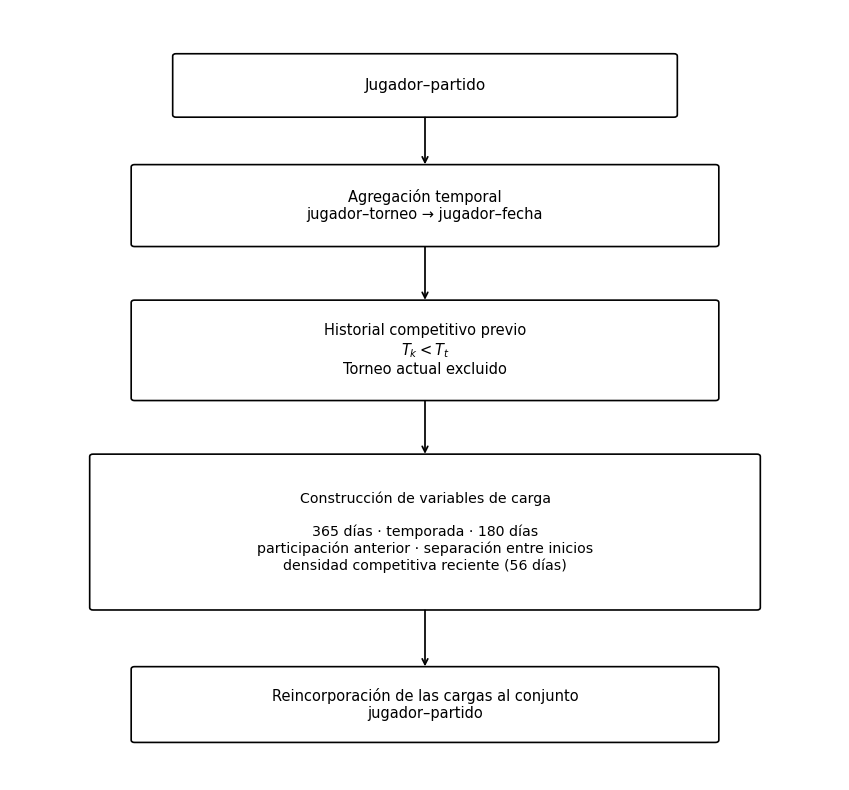

In [10]:
# ============================================================
# FIGURA PARA LA MEMORIA — ESQUEMA METODOLÓGICO CONCEPTUAL
# ============================================================


fig, ax = plt.subplots(figsize=(8.6, 8.0))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12.5)
ax.axis("off")


# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def dibujar_caja(x, y, ancho, alto, texto, fontsize=10, lw=1.2):
    caja = FancyBboxPatch(
        (x, y),
        ancho,
        alto,
        boxstyle="round,pad=0.04",
        facecolor="white",
        edgecolor="black",
        linewidth=lw
    )
    ax.add_patch(caja)

    ax.text(
        x + ancho / 2,
        y + alto / 2,
        texto,
        ha="center",
        va="center",
        fontsize=fontsize
    )


def flecha_vertical(y_superior, y_inferior):
    ax.annotate(
        "",
        xy=(5, y_inferior),
        xytext=(5, y_superior),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.25
        )
    )


# ------------------------------------------------------------
# Cajas del esquema
# ------------------------------------------------------------

dibujar_caja(
    2.0, 10.8, 6.0, 0.95,
    "Jugador–partido",
    fontsize=11
)

dibujar_caja(
    1.5, 8.7, 7.0, 1.25,
    "Agregación temporal\n"
    "jugador–torneo → jugador–fecha",
    fontsize=10.5
)

dibujar_caja(
    1.5, 6.2, 7.0, 1.55,
    "Historial competitivo previo\n"
    "$T_k < T_t$\n"
    "Torneo actual excluido",
    fontsize=10.5
)

dibujar_caja(
    1.0, 2.8, 8.0, 2.45,
    "Construcción de variables de carga\n\n"
    "365 días · temporada · 180 días\n"
    "participación anterior · separación entre inicios\n"
    "densidad competitiva reciente (56 días)",
    fontsize=10.2
)

dibujar_caja(
    1.5, 0.65, 7.0, 1.15,
    "Reincorporación de las cargas al conjunto\n"
    "jugador–partido",
    fontsize=10.5
)


# ------------------------------------------------------------
# Flechas
# ------------------------------------------------------------

flecha_vertical(10.8, 9.95)
flecha_vertical(8.7, 7.75)
flecha_vertical(6.2, 5.25)
flecha_vertical(2.8, 1.8)


plt.tight_layout()
plt.show()

# Si la figura queda bien y quieres exportarla después, descomenta:
# fig.savefig(
#     "fig_4_1_esquema_metodologico_cargas.png",
#     dpi=300,
#     bbox_inches="tight"
# )

## Guardado de los conjuntos de datos enriquecidos

Una vez superadas las comprobaciones estructurales y temporales, guardo los tres conjuntos de datos construidos durante esta fase:

* el conjunto principal jugador–partido;
* la tabla intermedia jugador–torneo;
* la tabla temporal jugador–fecha.

El conjunto principal contiene las variables originales, las medidas de carga acumulada y las nuevas variables de carga enriquecida. Será la base utilizada en las siguientes fases del trabajo para realizar el análisis exploratorio, estudiar la redundancia entre predictores y construir los modelos estadísticos y predictivos.

Las tablas jugador–torneo y jugador–fecha se conservan como estructuras auxiliares de trazabilidad. Estas permiten comprobar posteriormente cómo se construyeron las variables históricas sin tener que repetir todo el procesamiento temporal.


In [11]:
# ============================================================
# GUARDADO DE LOS DATASETS DE CARGA ENRIQUECIDA
# ============================================================

ruta_data = "df_jugador_cargas_enriquecidas.csv"
ruta_torneo = "df_jugador_torneo_enriquecido.csv"
ruta_fecha = "df_jugador_fecha_enriquecido.csv"

# Comprobaciones finales antes de guardar.
assert len(data) == filas_iniciales
assert data["_id_partido"].nunique() == partidos_iniciales

assert len(df_jugador_torneo) == filas_torneo_iniciales
assert len(df_jugador_fecha) == filas_fecha_iniciales

numero_columnas_enriquecidas = len(columnas_carga_enriquecida)

assert data.shape[1] == (
    columnas_iniciales + numero_columnas_enriquecidas
)

assert df_jugador_torneo.shape[1] == (
    columnas_torneo_iniciales + numero_columnas_enriquecidas
)

assert df_jugador_fecha.shape[1] == (
    columnas_fecha_iniciales + 1 + numero_columnas_enriquecidas
)

assert "bloque_temporal" in df_jugador_fecha.columns

# Dataset principal jugador–partido.
data.to_csv(
    ruta_data,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

# Tabla auxiliar jugador–torneo.
df_jugador_torneo.to_csv(
    ruta_torneo,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

# Tabla auxiliar jugador–fecha.
df_jugador_fecha.to_csv(
    ruta_fecha,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

print("Archivos guardados correctamente:")
print(f"- {ruta_data}: {data.shape}")
print(f"- {ruta_torneo}: {df_jugador_torneo.shape}")
print(f"- {ruta_fecha}: {df_jugador_fecha.shape}")

Archivos guardados correctamente:
- df_jugador_cargas_enriquecidas.csv: (94030, 101)
- df_jugador_torneo_enriquecido.csv: (50051, 38)
- df_jugador_fecha_enriquecido.csv: (50050, 35)
